# Import

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
import joblib
import json
import warnings
from sklearn.model_selection import GridSearchCV
warnings.filterwarnings('ignore')

RANDOM_STATE = 12

# Load data set

In [83]:
df = pd.read_csv(r"C:\Users\tommy\Downloads\Order_history.csv")
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True)
df['delivery_date'] = pd.to_datetime(df['delivery_date'], dayfirst=True)
df.head()

,order_id,customer_id,product_id,product_name,category,producer_id,quantity,price,order_date,delivery_date,order_total,status
0,1,11,48,Lemon Curd (300g),preserves,9,3,4.0,2025-04-04,2025-04-06,28.3,delivered
1,1,11,2,Heritage Potatoes (2kg),vegetables,2,3,3.5,2025-04-04,2025-04-06,28.3,delivered
2,1,11,26,Mature Cheddar (250g),dairy,3,1,5.8,2025-04-04,2025-04-06,28.3,delivered
3,2,11,2,Heritage Potatoes (2kg),vegetables,2,3,3.5,2025-04-13,2025-04-15,12.7,delivered
4,2,11,25,Semi Skimmed Milk (2 litres),dairy,3,1,2.2,2025-04-13,2025-04-15,12.7,delivered


# Check Data

In [84]:
print(f"Total rows: {len(df)}")
print(f"Unique customers: {df['customer_id'].nunique()}")
print(f"Unique products: {df['product_id'].nunique()}")
print(f"Unique orders: {df['order_id'].nunique()}")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"\nCategories: {df['category'].unique()}")

Total rows: 25087
Unique customers: 250
Unique products: 60
Unique orders: 8820
Date range: 2025-04-01 to 2026-03-30

Categories: ['preserves' 'vegetables' 'dairy' 'bakery' 'fruit' 'seasonal']


# Check Top Products

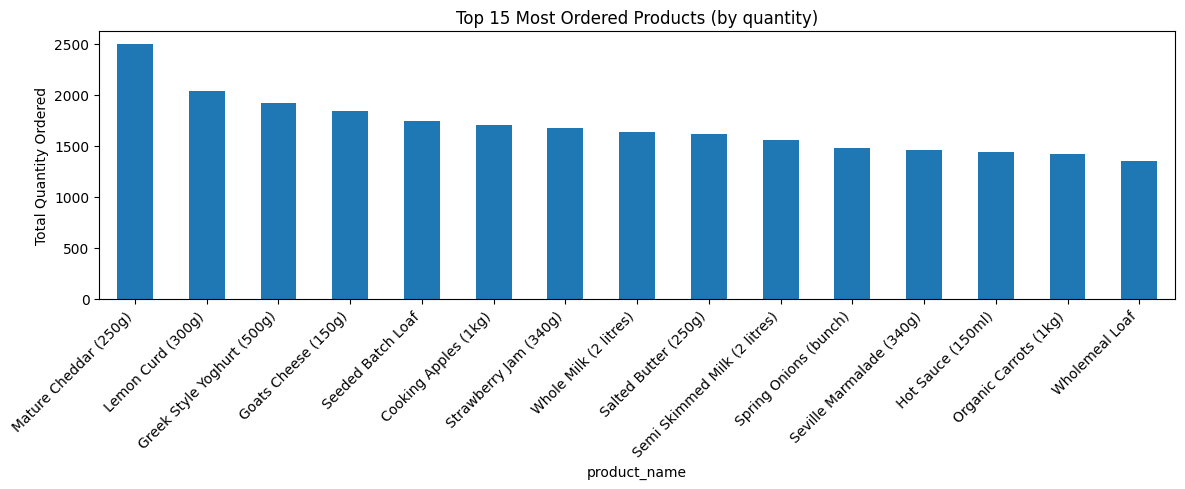

In [85]:
top_products = df.groupby('product_name')['quantity'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(12, 5))
top_products.plot(kind='bar')
plt.title('Top 15 Most Ordered Products (by quantity)')
plt.ylabel('Total Quantity Ordered')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('top_products.png', dpi=120)
plt.show()

# Orders Per Customer



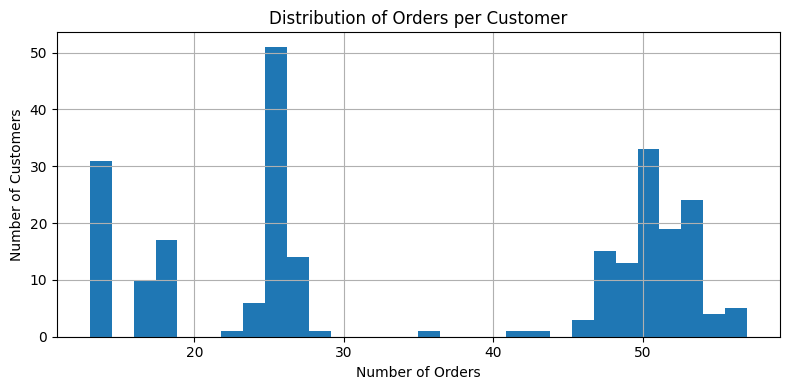

In [86]:
orders_per_customer = df.groupby('customer_id')['order_id'].nunique()

plt.figure(figsize=(8, 4))
orders_per_customer.hist(bins=30)
plt.title('Distribution of Orders per Customer')
plt.xlabel('Number of Orders')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.savefig('orders_per_customer.png', dpi=120)
plt.show()

# Train model 80/20 split
Use 80th percentile of order dates as the cutoff.
Everything before = what the model sees to build features.
Everything after  = the "future" used to generate the target label.

In [87]:

cutoff_date = df['order_date'].quantile(0.8)

train_df = df[df['order_date'] <= cutoff_date].copy()
future_df = df[df['order_date'] > cutoff_date].copy()

print(f"Cutoff date:          {cutoff_date.date()}")
print(f"Training period rows: {len(train_df)}")
print(f"Future period rows:   {len(future_df)}")

Cutoff date:          2026-01-13
Training period rows: 20069
Future period rows:   5018


# Feature engineering 
Built on 80th percentile training data 
- Order count
- Days since last order
- Avg quanitity (per order)
- Order gap std (how conistent the spacing between orders are. Low = regular, high = erratic)
- Total spend (how much theyve spent on that particular product
- Customer total orders (how active the customer is overall)
- Product popularity (how popular that producty is across all customers

In [88]:
reference_date = cutoff_date

# How many times each customer has ordered each product
order_counts = (
    train_df.groupby(['customer_id', 'product_id'])
    .size().reset_index(name='order_count')
)

# How recently they last ordered it
last_order = (
    train_df.groupby(['customer_id', 'product_id'])['order_date']
    .max().reset_index()
)
last_order['days_since_last_order'] = (reference_date - last_order['order_date']).dt.days
last_order = last_order.drop(columns='order_date')

# Average quantity purchased per order
avg_qty = (
    train_df.groupby(['customer_id', 'product_id'])['quantity']
    .mean().reset_index(name='avg_quantity')
)

# Order regularity (std of gaps between orders in days)
def order_gap_std(dates):
    if len(dates) < 2:
        return np.nan
    sorted_dates = sorted(dates)
    gaps = [(sorted_dates[i+1] - sorted_dates[i]).days for i in range(len(sorted_dates)-1)]
    return float(np.std(gaps))

regularity = (
    train_df.groupby(['customer_id', 'product_id'])['order_date']
    .apply(order_gap_std).reset_index(name='order_gap_std')
)

# Total spend on that product
total_spend = (
    train_df.assign(spend=train_df['quantity'] * train_df['price'])
    .groupby(['customer_id', 'product_id'])['spend']
    .sum().reset_index(name='total_spend')
)

# Customer-level context: how many distinct orders has this customer placed overall?
customer_order_count = (
    train_df.groupby('customer_id')['order_id']
    .nunique().reset_index(name='customer_total_orders')
)

# Product-level context: how popular is this product overall?
product_popularity = (
    train_df.groupby('product_id')['order_id']
    .nunique().reset_index(name='product_popularity')
)

features = (
    order_counts
    .merge(last_order, on=['customer_id', 'product_id'])
    .merge(avg_qty, on=['customer_id', 'product_id'])
    .merge(regularity, on=['customer_id', 'product_id'])
    .merge(total_spend, on=['customer_id', 'product_id'])
    .merge(customer_order_count, on='customer_id')
    .merge(product_popularity, on='product_id')
)

# Customers who only ordered once have no gap — fill with a large value (acts like "very irregular")
features['order_gap_std'] = features['order_gap_std'].fillna(features['order_gap_std'].max())

features.head()

,customer_id,product_id,order_count,days_since_last_order,avg_quantity,order_gap_std,total_spend,customer_total_orders,product_popularity
0,11,2,39,3,2.076923,2.40109,283.5,42,353
1,11,14,1,93,2.000000,126.50000,7.0,42,423
2,11,15,1,38,4.000000,126.50000,15.2,42,362
3,11,16,1,144,4.000000,126.50000,18.0,42,315
4,11,17,1,140,4.000000,126.50000,15.2,42,130


# Create targets using future data 
built on 20 percentile data
Take every unique cuistomer product pair that shows up after the cutoff and lavel them 1 (will reorder)
Merge bnack onto features table. Any pair that wasnt in the future gets labelled 0 (did not reorder)
- Every row has features and will_reorder boolean 

In [89]:
# Target: did this customer actually buy this product again after the cutoff?
future_pairs = future_df[['customer_id', 'product_id']].drop_duplicates()
future_pairs['will_reorder'] = 1

features = features.merge(future_pairs, on=['customer_id', 'product_id'], how='left')
features['will_reorder'] = features['will_reorder'].fillna(0).astype(int)

print(features['will_reorder'].value_counts())
print(f"\nPositive class rate: {features['will_reorder'].mean():.2%}")

will_reorder
0    990
1    937
Name: count, dtype: int64

Positive class rate: 48.62%


# train test split

In [90]:
feature_cols = [
    'order_count',
    'days_since_last_order',
    'avg_quantity',
    'order_gap_std',
    'total_spend',
    'customer_total_orders',
    'product_popularity',
]

X = features[feature_cols]
y = features['will_reorder']

# Stratified split so class ratio is preserved
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 1541, Test size: 386


# Train Model
Using Random Forest

In [112]:
model = RandomForestClassifier(
    n_estimators=400,
    max_depth=16,
    min_samples_leaf=3, #didnt choose 1 as its riskier for overfitting even though grid search recommended. Flaw of synthetic data
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
model.fit(X_train, y_train)
print("Model trained.")

Model trained.


# Grid search 
output: 
- Best parameters: {'max_depth': 16, 'min_samples_leaf': 1, 'n_estimators': 400}
- Best CV ROC AUC: 0.9839

In [105]:

# param_grid = {
#     'n_estimators': [200, 300, 400, 600],
#     'max_depth': [8, 12, 16],
#     'min_samples_leaf': [1, 5, 10 ,20],
# }

# base_model = RandomForestClassifier(
#     class_weight='balanced',
#     n_jobs=-1,
#     random_state=RANDOM_STATE,
# )

# grid_search = GridSearchCV(
#     estimator=base_model,
#     param_grid=param_grid,
#     scoring='roc_auc',   # optimise for ROC AUC rather than raw accuracy
#     cv=3,                # 3-fold cross-validation
#     n_jobs=-1,
#     verbose=1,
# )

# grid_search.fit(X_train, y_train)

# print(f"\nBest parameters: {grid_search.best_params_}")
# print(f"Best CV ROC AUC: {grid_search.best_score_:.4f}")

# # Use the best model from here on
# model = grid_search.best_estimator_

# Classification Report + ROC AUC


In [113]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Will Not Reorder', 'Will Reorder']))
print(f"ROC AUC: {roc_auc_score(y_test, y_proba):.4f}")

                  precision    recall  f1-score   support

Will Not Reorder       0.99      0.99      0.99       198
    Will Reorder       0.99      0.99      0.99       188

        accuracy                           0.99       386
       macro avg       0.99      0.99      0.99       386
    weighted avg       0.99      0.99      0.99       386

ROC AUC: 0.9981


# Confusion Matrix

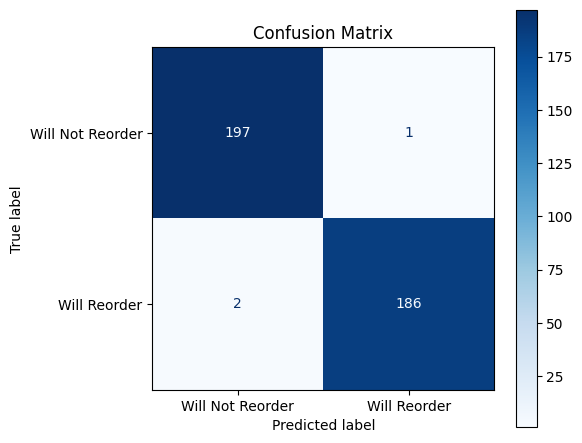

In [114]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Will Not Reorder', 'Will Reorder'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120)
plt.show()

# Feature Importance

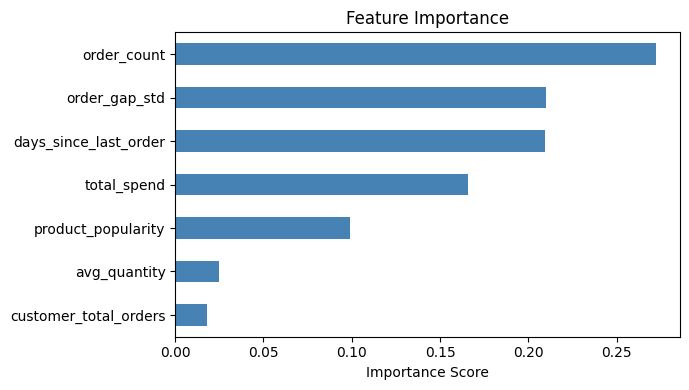

In [115]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importances.plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120)
plt.show()

# Demand Forecasting (Bonus)

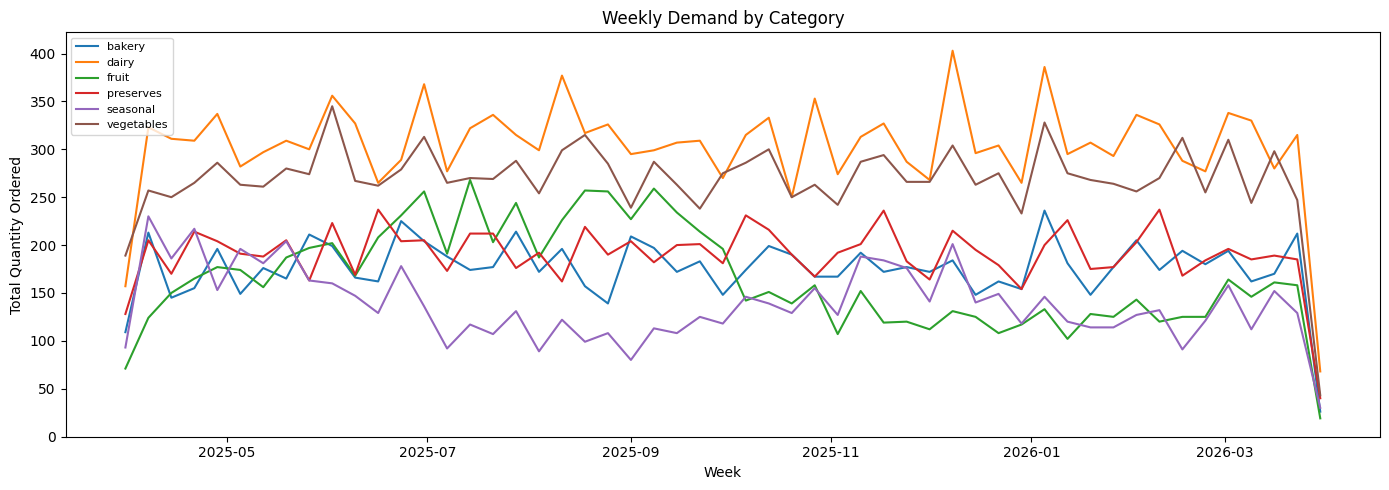

In [116]:
df['week'] = df['order_date'].dt.to_period('W')
weekly_demand = df.groupby(['week', 'category'])['quantity'].sum().reset_index()
weekly_demand['week_dt'] = weekly_demand['week'].dt.to_timestamp()

plt.figure(figsize=(14, 5))
for cat in weekly_demand['category'].unique():
    subset = weekly_demand[weekly_demand['category'] == cat]
    plt.plot(subset['week_dt'], subset['quantity'], label=cat)

plt.title('Weekly Demand by Category')
plt.xlabel('Week')
plt.ylabel('Total Quantity Ordered')
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig('weekly_demand.png', dpi=120)
plt.show()

# Example
Top re-oprder recommendations for customers

In [117]:
# Demonstrates what the FastAPI endpoint would return
def recommend_reorders(customer_id, top_n=5):
    cust_rows = features[features['customer_id'] == customer_id]
    if cust_rows.empty:
        return pd.DataFrame()
    probs = model.predict_proba(cust_rows[feature_cols])[:, 1]
    out = cust_rows[['customer_id', 'product_id']].copy()
    out['reorder_probability'] = probs
    return out.sort_values('reorder_probability', ascending=False).head(top_n)

sample_customer = features['customer_id'].iloc[0]
print(f"Top 5 recommendations for customer {sample_customer}:")
recommend_reorders(sample_customer, top_n=5)

Top 5 recommendations for customer 11:


,customer_id,product_id,reorder_probability
10,11,48,1.000000
0,11,2,0.999522
8,11,28,0.257958
3,11,16,0.079656
7,11,26,0.065193


# Save model + metadata

In [118]:
joblib.dump(model, 'order_prediction_model.pkl')

metadata = {
    "model_type": "RandomForestClassifier",
    "features": feature_cols,
    "target": "will_reorder",
    "target_definition": (
        "1 if customer-product pair reappeared in orders after the cutoff date, else 0"
    ),
    "cutoff_date": str(cutoff_date.date()),
    "reference_date": str(reference_date.date()),
    "hyperparameters": {
        "n_estimators": 400,
        "max_depth": 16,
        "min_samples_leaf": 3, #didnt choose 1 as its riskier for overfitting even though grid search recommended. Flaw of synthetic data
        "class_weight": "balanced",
        "random_state": RANDOM_STATE,
    },
    "test_metrics": {
        "accuracy": float((y_pred == y_test).mean()),
        "roc_auc": float(roc_auc_score(y_test, y_proba)),
    },
    "feature_order": feature_cols,
    "notes": (
        "Binary classifier over (customer, product) pairs. Features engineered from "
        "orders up to cutoff_date; target derived from orders after cutoff_date. "
        "Input DataFrame must provide columns in feature_order exactly."
    ),
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Saved: order_prediction_model.pkl")
print("Saved: model_metadata.json")
print(f"Test Accuracy: {metadata['test_metrics']['accuracy']:.4f}")
print(f"Test ROC AUC: {metadata['test_metrics']['roc_auc']:.4f}")

Saved: order_prediction_model.pkl
Saved: model_metadata.json
Test Accuracy: 0.9922
Test ROC AUC: 0.9981
